<center>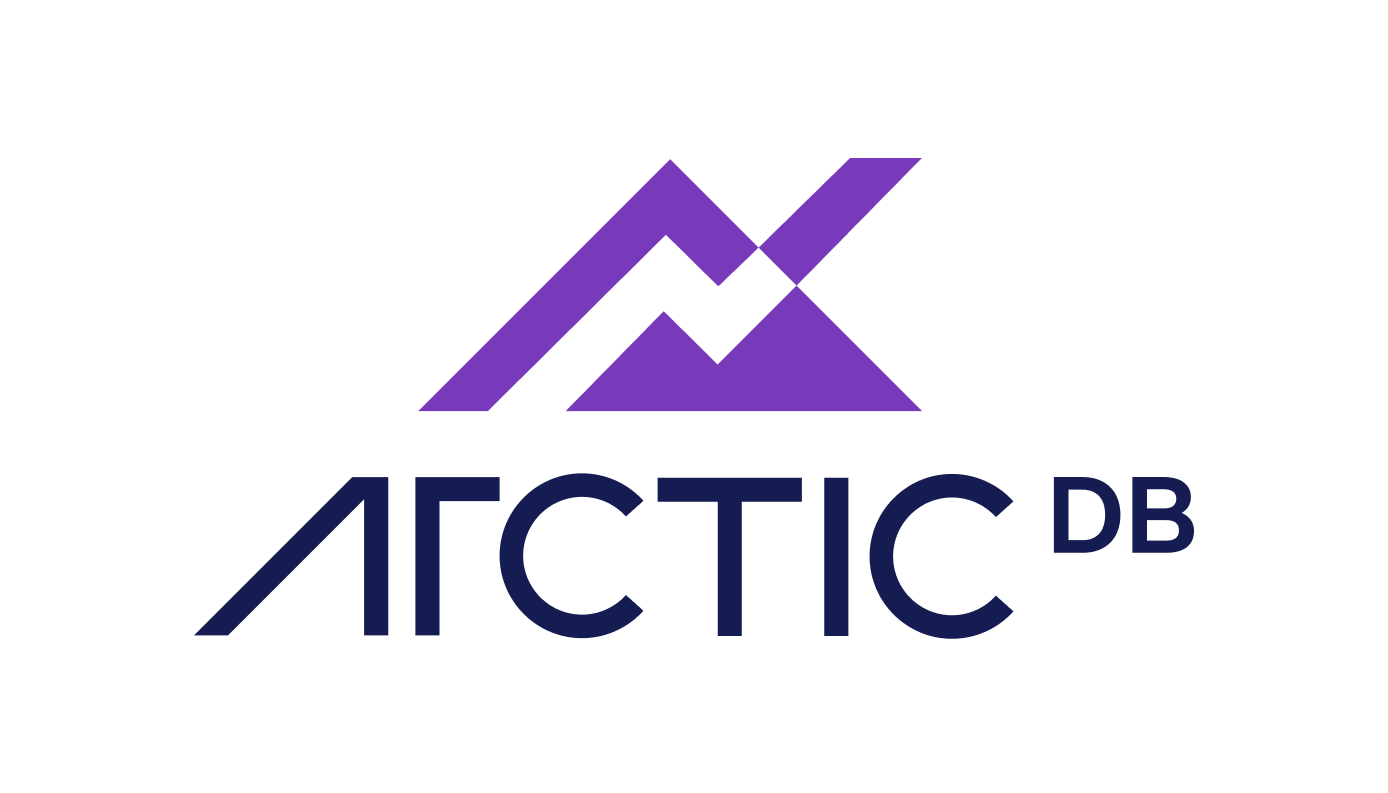
</center>

# ArcticDB Data Compaction Demo

This demo notebook demonstrates the `compact_data` and `compact_data_batch` methods for reslicing data on disk in order to optimise read performance, and the accompanying `compact_data_explain_plan` method. It also covers the `compact_data` argument to `append` and `append_batch`.

* After running `compact_data` or `compact_data_batch` against a symbol, all chunks on disk are guaranteed to have a row-count within 33% of some target value.
    * This target value defaults to the `rows_per_segment` library config setting if not specified.
* The compaction operates on the latest live version of the symbol, and creates a new version unless the data is already suitably compacted.
* The metadata from the latest live version is maintained by the `compact_data` method.
* `compact_data_explain_plan` is like a dry run of the compaction, showing what the effect of running `compact_data` or `compact_data_batch` would be. No actual data is read from or written to disk.
* Setting `compact_data=True` with `append` or `append_batch` is similar to appending the data with the flag set to `False` (the default), and then compacting the data with one of the standalone methods. Only one new version is created though.
    * In this case, the `rows_per_segment` is not specifiable, it will always be taken from the library config setting.

For more information about the on-disk data format, see [this section](https://docs.arcticdb.io/latest/technical/on_disk_storage/) of the documentation, as well as the [documentation](https://docs.arcticdb.io/latest/api/arctic/#arcticdb.LibraryOptions) for the `rows_per_segment` library configuration option.

## Setup

In [1]:
!pip install arcticdb

In [2]:
# To ensure reproducible performance measurements
import os
os.environ["ARCTICDB_VersionStore_NumCPUThreads_int"] = "4"

In [3]:
import numpy as np
import pandas as pd
import arcticdb as adb

In [4]:
rng = np.random.default_rng()

In [5]:
# object store
arctic = adb.Arctic("lmdb://arcticdb_compact_data")

In [6]:
# So that each run of the notebook starts from an empty library
arctic.delete_library("compact_data")
# library - rows_per_segment not specified, so will default to 100,000
lib = arctic.get_library("compact_data", create_if_missing=True)
# symbol
sym = "OHLCV_minutely"

## The `compact_data` method

## Create Some Data

* Simulate open-high-low-close-volume (OHLCV) minutely data since the turn of the millennium
* Writing pattern is to append one day's worth of data at a time
* This will create 1 data key for each call to append

In [7]:
days = pd.date_range("2000-01-01", "2026-01-01", freq="B")
len(days)

6784

In [8]:
def generate_day_data(day):
    minutely_ts = pd.date_range(day + pd.Timedelta(hours=8), day + pd.Timedelta(hours=16), freq="min")
    num_rows = len(minutely_ts)
    return pd.DataFrame({"open": rng.random(num_rows), "high": rng.random(num_rows), "low": rng.random(num_rows), "close": rng.random(num_rows), "volume": rng.random(num_rows)}, index=minutely_ts)

In [9]:
for day in days:
    df = generate_day_data(day)
    lib.append(sym, df, metadata=f"some metadata {day}")

### This reads 6,784 data keys:

In [10]:
%%timeit
lib.read(sym)

61.1 ms ± 6.79 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
vit_before_compaction = lib.read(sym)
vit_before_compaction.data

,open,high,low,close,volume
2000-01-03 08:00:00,0.903196,0.287042,0.310028,0.465643,0.850770
2000-01-03 08:01:00,0.726307,0.976634,0.716546,0.695378,0.278450
2000-01-03 08:02:00,0.305082,0.343486,0.042017,0.550290,0.552388
2000-01-03 08:03:00,0.722134,0.141257,0.488456,0.835750,0.395513
2000-01-03 08:04:00,0.928394,0.744513,0.785123,0.862236,0.087003
...,...,...,...,...,...
2026-01-01 15:56:00,0.376040,0.019941,0.372354,0.176808,0.978362
2026-01-01 15:57:00,0.476032,0.130399,0.674303,0.730136,0.248132
2026-01-01 15:58:00,0.409921,0.260924,0.186574,0.393183,0.574988
2026-01-01 15:59:00,0.573795,0.151552,0.268032,0.535715,0.904988


In [12]:
vit_before_compaction.version

6783

In [13]:
vit_before_compaction.metadata

'some metadata 2026-01-01 00:00:00'

## Find out what impact calling `compact_data` would have

In [14]:
compact_data_info = lib.compact_data_explain_plan(sym)
compact_data_info

CompactDataInfo(will_do_work=true, version_id_before=6783, version_id_after=6784, num_row_slices_before=6784, num_row_slices_after=33)

* `will_do_work` - whether calling `compact_data` will do any compaction, or do nothing if the data is already suitably compacted
* `version_id_before` - the version number of the latest live version right now
* `version_id_after` - the version number of the latest version after calling `compact_data`
* `num_row_slices_before` - how many row-slices the data is comprised of right now
* `num_row_slices_after` - how many row-slices the data will have after calling `compact_data`

In addition to the fields shown in the string representation above, there are also lists that show the row-slice boundaries before and after compaction.

Before compaction, every row slice has 481 rows:

In [15]:
compact_data_info.row_slices_before[:5]

[0, 481, 962, 1443, 1924]

In [16]:
compact_data_info.row_slices_before[-5:]

[3261180, 3261661, 3262142, 3262623, 3263104]

### After compaction, every row-slice will have 100,000 ±33% rows. This is because we did not specify the `rows_per_segment` argument, and so it used the library default of 100,000:

In [17]:
compact_data_info.row_slices_after

[0,
 100048,
 200096,
 300144,
 400192,
 500240,
 600288,
 700336,
 800384,
 900432,
 1000480,
 1100528,
 1200576,
 1300624,
 1400672,
 1500720,
 1600768,
 1700816,
 1800864,
 1900912,
 2000960,
 2101008,
 2201056,
 2301104,
 2401152,
 2501200,
 2601248,
 2701296,
 2801344,
 2901392,
 3001440,
 3101488,
 3182296,
 3263104]

### Print the number of rows in each slice after compaction:

In [18]:
for idx in range(len(compact_data_info.row_slices_after) - 1):
    print(compact_data_info.row_slices_after[idx + 1] - compact_data_info.row_slices_after[idx])

100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
80808
80808


### Note that the row-slices do not all have the same number of rows post-compaction. The reasoning for this will be explained below.

# Compact the data!

In [19]:
lib.compact_data(sym)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6784, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1785934997582081646)

### Like other modification operations, this returns a `VersionedItem` containing information about the version that was just written

### The data is unchanged, but now only 33 (larger) data keys need to be read. This is of particular benefit on higher latency storages where bandwidth isn't an issue, but each IO round trip adds 10s or 100s of milliseconds

In [20]:
%%timeit
lib.read(sym)

22.5 ms ± 1.07 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Even on LMDB storage with zero latency, runs ~x3.5 faster!

In [21]:
vit_after_compaction = lib.read(sym)
vit_after_compaction.data

,open,high,low,close,volume
2000-01-03 08:00:00,0.903196,0.287042,0.310028,0.465643,0.850770
2000-01-03 08:01:00,0.726307,0.976634,0.716546,0.695378,0.278450
2000-01-03 08:02:00,0.305082,0.343486,0.042017,0.550290,0.552388
2000-01-03 08:03:00,0.722134,0.141257,0.488456,0.835750,0.395513
2000-01-03 08:04:00,0.928394,0.744513,0.785123,0.862236,0.087003
...,...,...,...,...,...
2026-01-01 15:56:00,0.376040,0.019941,0.372354,0.176808,0.978362
2026-01-01 15:57:00,0.476032,0.130399,0.674303,0.730136,0.248132
2026-01-01 15:58:00,0.409921,0.260924,0.186574,0.393183,0.574988
2026-01-01 15:59:00,0.573795,0.151552,0.268032,0.535715,0.904988


In [22]:
vit_before_compaction.data.equals(vit_after_compaction.data)

True

### A new version has been created:

In [23]:
vit_after_compaction.version

6784

### The metadata is the same as the version that got compacted:

In [24]:
vit_after_compaction.metadata

'some metadata 2026-01-01 00:00:00'

# Now suppose a data vendor restates a single days worth of data:

In [25]:
day = days[1_000]
df = generate_day_data(day)
lib.update(sym, df)
df

,open,high,low,close,volume
2003-11-03 08:00:00,0.582366,0.146977,0.656918,0.290471,0.483627
2003-11-03 08:01:00,0.397897,0.230768,0.596099,0.613895,0.106646
2003-11-03 08:02:00,0.123893,0.647533,0.210100,0.579464,0.228911
2003-11-03 08:03:00,0.015324,0.760227,0.185393,0.012468,0.157286
2003-11-03 08:04:00,0.670147,0.349669,0.281271,0.658520,0.667422
...,...,...,...,...,...
2003-11-03 15:56:00,0.059694,0.965551,0.219874,0.880971,0.625992
2003-11-03 15:57:00,0.448745,0.969533,0.881961,0.976806,0.990011
2003-11-03 15:58:00,0.169475,0.339409,0.738013,0.512463,0.517097
2003-11-03 15:59:00,0.892093,0.206302,0.791956,0.174379,0.669368


In [26]:
compact_data_info = lib.compact_data_explain_plan(sym)
compact_data_info

CompactDataInfo(will_do_work=true, version_id_before=6785, version_id_after=6786, num_row_slices_before=35, num_row_slices_after=33)

In [27]:
compact_data_info.row_slices_before[4:8]

[400192, 481000, 481481, 500240]

In [28]:
compact_data_info.row_slices_after[4:6]

[400192, 500240]

## The 3 row-slices spanning rows 400,192 to 500,240 will be combined into 1
These cover the timestamps from `2003-03-12` to `2003-12-26` i.e. the date that was restated, plus some surrounding dates.

No other row-slices in the data will be compacted, as they are already suitably sized, and therefore do not need to be read, processed, and rewritten. This is why compaction does not necessarily produce uniform numbers of rows in each slice, as this can result in small appends or updates triggering all of the data to be rewritten during the compaction.

In [29]:
lib.compact_data(sym)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6786, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1785934999543172806)

## The data has just been compacted, and so compacting again immediately will have no effect:

In [30]:
lib.compact_data_explain_plan(sym)

CompactDataInfo(will_do_work=false, version_id_before=6786, version_id_after=6786, num_row_slices_before=33, num_row_slices_after=33)

## If the library default `rows_per_segment` is not appropriate for a symbol, this can be explicitly specified to both methods

In [31]:
lib.compact_data_explain_plan(sym, rows_per_segment=1_000_000)

CompactDataInfo(will_do_work=true, version_id_before=6786, version_id_after=6787, num_row_slices_before=33, num_row_slices_after=3)

In [32]:
lib.compact_data(sym, rows_per_segment=1_000_000)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6787, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1785934999760942648)

### This can also be used to slice into smaller segments if this aids read performance

In [33]:
lib.compact_data_explain_plan(sym, rows_per_segment=10_000)

CompactDataInfo(will_do_work=true, version_id_before=6787, version_id_after=6788, num_row_slices_before=3, num_row_slices_after=247)

In [34]:
lib.compact_data(sym, rows_per_segment=10_000)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6788, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1785934999959716837)

## The `compact_data_batch` method

This is identical to the `compact_data` method, but operates on a collection of symbols

In [35]:
# Generate 10 symbols of fragmented minutely OHLCV volume data
syms = [f"{sym}_{i}" for i in range(10)]
for day in days:
    df = generate_day_data(day)
    lib.append_batch([adb.WritePayload(sym, df) for sym in syms])

# Also add one non-fragmented symbol
df = pd.DataFrame({"col": np.arange(1_000_000)})
lib.write("non-fragmented", df)

VersionedItem(symbol='non-fragmented', library='compact_data', data=n/a, version=0, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1785935145603435349)

### This reads 67,840 data keys:

In [36]:
%%timeit
lib.read_batch(syms)

443 ms ± 25.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [37]:
res = lib.compact_data_batch(syms + ["non-fragmented"])

In [38]:
# The non-fragmented symbol is still on version 0, as it did not need compacting
res[10].version

0

### This reads 330 data keys:

In [39]:
%%timeit
lib.read_batch(syms)

112 ms ± 8.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## The `compact_data` argument to `append` and `append_batch`

Does the compaction in-line as part of the append

In [40]:
lib.delete(sym)
lib_tool = lib._dev_tools.library_tool()
# Where previously 1 data key would be created on every call to append, now they are compacted together
for idx, day in enumerate(days):
    df = generate_day_data(day)
    lib.append(sym, df, compact_data=True)
    if (idx + 1) % 500 == 0:
        print(f"After {idx + 1} appends there are {len(lib_tool.read_index(sym))} data keys")

After 500 appends there are 3 data keys
After 1000 appends there are 7 data keys
After 1500 appends there are 10 data keys
After 2000 appends there are 14 data keys
After 2500 appends there are 17 data keys
After 3000 appends there are 21 data keys
After 3500 appends there are 25 data keys
After 4000 appends there are 28 data keys
After 4500 appends there are 32 data keys
After 5000 appends there are 35 data keys
After 5500 appends there are 39 data keys
After 6000 appends there are 43 data keys
After 6500 appends there are 46 data keys


### Note that if the data is fragmented, and then `append` or `append_batch` is called with `compact_data=True` then the whole symbol will be compacted. This can take longer and use a lot more memory than if the majority of the data is already well compacted.

In [41]:
lib.delete(sym)
for day in days[:-1]:
    df = generate_day_data(day)
    lib.append(sym, df, compact_data=False)
print(f"Before compaction there are {len(lib_tool.read_index(sym))} data keys")
df = generate_day_data(days[-1])
lib.append(sym, df, compact_data=True)
print(f"After append with compact_data=True there are {len(lib_tool.read_index(sym))} data keys")

Before compaction there are 6783 data keys
After append with compact_data=True there are 33 data keys


### The argument works in exactly the same way with `append_batch`

In [42]:
df = generate_day_data(days[0])
lib.write_batch([adb.WritePayload(sym, df) for sym in syms])
df = generate_day_data(days[1])
lib.append_batch([adb.WritePayload(sym, df) for sym in syms], compact_data=True)
print(f"There is {len(lib_tool.read_index(syms[0]))} data key for each symbol")

There is 1 data key for each symbol
